In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, log_loss
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

In [69]:
# Load the data
df = pd.read_csv('spambase.data', header=None)

print("Shape:", df.shape)
print("Number of features:", df.shape[1] - 1)
print("Number of samples:", df.shape[0])
df.head()

Shape: (4601, 58)
Number of features: 57
Number of samples: 4601


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [70]:
# Separate features and labels
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("\nClass counts:")
print(y.value_counts())

Features shape: (4601, 57)
Labels shape: (4601,)

Class counts:
57
0    2788
1    1813
Name: count, dtype: int64


## [C] Problem 1: Logistic regression (25 points)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3450
Testing samples: 1151


In [72]:
# Create and train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 ... 1 0 0]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
# 1.1a: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("TN (True Negative):", cm[0,0])
print("FP (False Positive):", cm[0,1])
print("FN (False Negative):", cm[1,0])
print("TP (True Positive):", cm[1,1])

Confusion Matrix:
[[650  26]
 [ 58 417]]
TN (True Negative): 650
FP (False Positive): 26
FN (False Negative): 58
TP (True Positive): 417


In [74]:
# 1.1b:  Accuracy and Error
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print("Accuracy:", round(accuracy, 4))
print("Error:", round(error, 4))

Accuracy: 0.927
Error: 0.073


In [75]:
# 1.1c: Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Precision: 0.9413
Recall: 0.8779
F1 Score: 0.9085


In [76]:
# 1.2: Feature Coefficients

# Get coefficients from model
coef = model.coef_[0]

# Create simple table
coef_df = pd.DataFrame({
    'feature': range(57),
    'coefficient': coef
})
coef_df = coef_df.sort_values('coefficient', ascending=False)

print("Coefficients (sorted high to low):")
print(coef_df)

# Most important features
print(f"\nMost positive: Feature {coef.argmax()} ({coef.max():.4f})")
print(f"Most negative: Feature {coef.argmin()} ({coef.min():.4f})")

# Count
print(f"\nPositively correlated: {sum(coef > 0)} features")
print(f"Negatively correlated: {sum(coef < 0)} features")

Coefficients (sorted high to low):
    feature  coefficient
52       52     3.247768
22       22     2.381522
6         6     2.233783
14       14     1.154980
35       35     1.092929
15       15     1.034438
19       19     0.947807
53       53     0.938559
16       16     0.817725
3         3     0.670976
8         8     0.657152
4         4     0.629067
5         5     0.621816
7         7     0.564632
23       23     0.395667
27       27     0.332717
20       20     0.255865
21       21     0.247751
51       51     0.225114
2         2     0.158089
13       13     0.099264
18       18     0.095420
17       17     0.084300
9         9     0.046540
12       12     0.030366
55       55     0.006790
56       56     0.000923
54       54    -0.011508
33       33    -0.016041
36       36    -0.070789
31       31    -0.088652
39       39    -0.095665
11       11    -0.113433
1         1    -0.123234
49       49    -0.213318
0         0    -0.214158
30       30    -0.289810
50       50    

In [77]:
# 1.3 
# Get probability predictions
y_prob = model.predict_proba(X_test)[:, 1]

thresholds = [0.25, 0.5, 0.75, 0.9]

# Create empty dictionary
results = {}

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    
    results[t] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
        }

# Convert to DataFrame for nice display
results_df = pd.DataFrame(results).T 

# Results
print(results_df)

# Comment on trends
# Accuracy: Best accuracy around threshold = 0.50
# Precision: Higher threshold = higher precision
# Recall: Higher threshold = lower recall


      Accuracy  Precision    Recall
0.25  0.907906   0.839779  0.960000
0.50  0.927020   0.941309  0.877895
0.75  0.889661   0.960317  0.764211
0.90  0.822763   0.968858  0.589474


## [C] Problem 2: Gradient Descent for Logistic regression (25 points)

In [78]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3450, 57)
X_test_scaled shape: (1151, 57)


In [79]:
# Gradient descent function (adapted from HW2)
def gradient_descent(X, y, alpha, num_iterations):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    N = X_b.shape[0]
    theta = np.zeros(X_b.shape[1])
    loss_history = []
    
    for i in range(num_iterations):
        z = X_b @ theta
        y_pred = 1 / (1 + np.exp(-z))  
        error = y_pred - y
        gradient = (1/N) * (X_b.T @ error)
        theta = theta - alpha * gradient
        loss = log_loss(y, y_pred)  
        loss_history.append(loss)
    
    return theta, loss_history

# Test the gradient descent function
test_theta, test_loss = gradient_descent(X_train_scaled, y_train.values, 0.01, 10)

print("Test run with alpha=0.01, 10 iterations:")
print("Theta shape:", test_theta.shape)
print("Number of losses recorded:", len(test_loss))
print("First loss:", round(test_loss[0], 4))
print("Last loss:", round(test_loss[-1], 4))



Test run with alpha=0.01, 10 iterations:
Theta shape: (58,)
Number of losses recorded: 10
First loss: 0.6931
Last loss: 0.655


In [80]:
# Predict function
def predict(X, theta):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    z = X_b @ theta
    y_pred = 1 / (1 + np.exp(-z))
    return (y_pred >= 0.5).astype(int)

# Test the predict function
test_predictions = predict(X_test_scaled, test_theta)

print("Test predictions:")
print("Shape:", test_predictions.shape)
print("First 10 predictions:", test_predictions[:10])
print("Unique values:", np.unique(test_predictions))

Test predictions:
Shape: (1151,)
First 10 predictions: [0 0 0 0 0 1 0 0 0 0]
Unique values: [0 1]


In [81]:
# Test 3 learning rates - Loss
results = []

for alpha in [0.001, 0.01, 0.1]:
    theta, loss_history = gradient_descent(X_train_scaled, y_train.values, alpha, 100)
    results.append({
        'Alpha': alpha,
        'Loss at 10': round(loss_history[9], 4),
        'Loss at 50': round(loss_history[49], 4),
        'Loss at 100': round(loss_history[99], 4)
    })

print("Cross-Entropy Loss:")
print(pd.DataFrame(results))

Cross-Entropy Loss:
   Alpha  Loss at 10  Loss at 50  Loss at 100
0  0.001      0.6890      0.6716       0.6517
1  0.010      0.6550      0.5436       0.4698
2  0.100      0.4766      0.3254       0.2895


In [82]:
# Metrics at 100 iterations
metrics = []

for alpha in [0.001, 0.01, 0.1]:
    theta, loss_history = gradient_descent(X_train_scaled, y_train.values, alpha, 100)
    y_pred = predict(X_test_scaled, theta)
    metrics.append({
        'Alpha': alpha,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4)
    })

print("Metrics at 100 Iterations:")
print(pd.DataFrame(metrics))

Metrics at 100 Iterations:
   Alpha  Accuracy  Precision  Recall      F1
0  0.001    0.8992     0.8811  0.8737  0.8774
1  0.010    0.9036     0.9009  0.8611  0.8805
2  0.100    0.9062     0.9238  0.8421  0.8811


In [83]:
# Compare with sklearn
sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train_scaled, y_train)

# Training set metrics
y_pred_train = sklearn_model.predict(X_train_scaled)

print("sklearn Training Set:")
print("Accuracy:", round(accuracy_score(y_train, y_pred_train), 4))
print("Precision:", round(precision_score(y_train, y_pred_train), 4))
print("Recall:", round(recall_score(y_train, y_pred_train), 4))
print("F1:", round(f1_score(y_train, y_pred_train), 4))

sklearn Training Set:
Accuracy: 0.9258
Precision: 0.924
Recall: 0.8812
F1: 0.9021


In [84]:
# Test set metrics
y_pred_test = sklearn_model.predict(X_test_scaled)

print("sklearn Test Set:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_test), 4))
print("Precision:", round(precision_score(y_test, y_pred_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_test), 4))
print("F1:", round(f1_score(y_test, y_pred_test), 4))

sklearn Test Set:
Accuracy: 0.9227
Precision: 0.9406
Recall: 0.8674
F1: 0.9025


## [C] Problem 3: Comparing classifiers (25 points)

In [85]:
# 3.1: Cross-validation to select k for kNN

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results = []

for k in k_values:
    # Create kNN model with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 5-fold cross validation
    cv_acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    cv_prec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision').mean()
    cv_rec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall').mean()
    cv_err = 1 - cv_acc
    
    results.append({
        'k': k,
        'Accuracy': round(cv_acc, 4),
        'Error': round(cv_err, 4),
        'Precision': round(cv_prec, 4),
        'Recall': round(cv_rec, 4)
    })

print("Cross-Validation Results for kNN:")
print(pd.DataFrame(results))

Cross-Validation Results for kNN:
    k  Accuracy   Error  Precision  Recall
0   1    0.9014  0.0986     0.8777  0.8670
1   3    0.9009  0.0991     0.8825  0.8595
2   5    0.9026  0.0974     0.8906  0.8543
3   7    0.9067  0.0933     0.8963  0.8595
4   9    0.9049  0.0951     0.8994  0.8505
5  11    0.9006  0.0994     0.8977  0.8401
6  15    0.8988  0.1012     0.9017  0.8303
7  21    0.8907  0.1093     0.9002  0.8087


In [86]:
# Find best k (lowest error)
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Error'].idxmin(), 'k']

print("Best k value:", best_k)
print("This k has the lowest cross-validation error.")

Best k value: 7
This k has the lowest cross-validation error.


In [87]:
# 3.2: Create the three models

# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model 2: LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Model 3: kNN with best k
knn = KNeighborsClassifier(n_neighbors=int(best_k))
knn.fit(X_train_scaled, y_train)

# Training set metrics for all 3 models
train_metrics = []

# Logistic Regression - Training
y_pred_train = log_reg.predict(X_train_scaled)
train_metrics.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(accuracy_score(y_train, y_pred_train), 4),
    'Error': round(1 - accuracy_score(y_train, y_pred_train), 4),
    'Precision': round(precision_score(y_train, y_pred_train), 4),
    'Recall': round(recall_score(y_train, y_pred_train), 4)
})

# LDA - Training
y_pred_train = lda.predict(X_train_scaled)
train_metrics.append({
    'Model': 'LDA',
    'Accuracy': round(accuracy_score(y_train, y_pred_train), 4),
    'Error': round(1 - accuracy_score(y_train, y_pred_train), 4),
    'Precision': round(precision_score(y_train, y_pred_train), 4),
    'Recall': round(recall_score(y_train, y_pred_train), 4)
})

# kNN - Training
y_pred_train = knn.predict(X_train_scaled)
train_metrics.append({
    'Model': 'kNN',
    'Accuracy': round(accuracy_score(y_train, y_pred_train), 4),
    'Error': round(1 - accuracy_score(y_train, y_pred_train), 4),
    'Precision': round(precision_score(y_train, y_pred_train), 4),
    'Recall': round(recall_score(y_train, y_pred_train), 4)
})

print("Training Set Metrics:")
print(pd.DataFrame(train_metrics))

Training Set Metrics:
                 Model  Accuracy   Error  Precision  Recall
0  Logistic Regression    0.9258  0.0742     0.9240  0.8812
1                  LDA    0.8867  0.1133     0.9157  0.7795
2                  kNN    0.9226  0.0774     0.9167  0.8804


In [88]:
# Test set metrics for all 3 models

test_metrics = []

# Logistic Regression - Test
y_pred_test = log_reg.predict(X_test_scaled)
test_metrics.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(accuracy_score(y_test, y_pred_test), 4),
    'Error': round(1 - accuracy_score(y_test, y_pred_test), 4),
    'Precision': round(precision_score(y_test, y_pred_test), 4),
    'Recall': round(recall_score(y_test, y_pred_test), 4)
})

# LDA - Test
y_pred_test = lda.predict(X_test_scaled)
test_metrics.append({
    'Model': 'LDA',
    'Accuracy': round(accuracy_score(y_test, y_pred_test), 4),
    'Error': round(1 - accuracy_score(y_test, y_pred_test), 4),
    'Precision': round(precision_score(y_test, y_pred_test), 4),
    'Recall': round(recall_score(y_test, y_pred_test), 4)
})

# kNN - Test
y_pred_test = knn.predict(X_test_scaled)
test_metrics.append({
    'Model': 'kNN',
    'Accuracy': round(accuracy_score(y_test, y_pred_test), 4),
    'Error': round(1 - accuracy_score(y_test, y_pred_test), 4),
    'Precision': round(precision_score(y_test, y_pred_test), 4),
    'Recall': round(recall_score(y_test, y_pred_test), 4)
})

print("Test Set Metrics:")
print(pd.DataFrame(test_metrics))

Test Set Metrics:
                 Model  Accuracy   Error  Precision  Recall
0  Logistic Regression    0.9227  0.0773     0.9406  0.8674
1                  LDA    0.8853  0.1147     0.9298  0.7811
2                  kNN    0.9018  0.0982     0.9114  0.8442


# Observation:

Best Model: Logistic Regression has the highest test accuracy (0.9227) and also has the highest test precision (0.9406)

Worst Model: LDA has the lowest accuracy on both training (0.8867) and test (0.8853) and the lowest recall (0.7811)

KNN has the largest gap between train and test accuracy, suggesting slight overfitting.

In [89]:
# 3.3: ROC Curve using sklearn

# Get probability predictions from logistic regression
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Probability predictions:")
print("Shape:", y_prob.shape)
print("First 10 probabilities:", y_prob[:10].round(4))

Probability predictions:
Shape: (1151,)
First 10 probabilities: [1.749e-01 1.246e-01 2.220e-02 9.869e-01 1.410e-02 7.227e-01 3.000e-04
 0.000e+00 2.480e-02 5.321e-01]


In [90]:
# Calculate ROC curve using sklearn
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("Number of points:", len(fpr))
print("AUC:", round(roc_auc, 4))

Number of points: 164
AUC: 0.9747


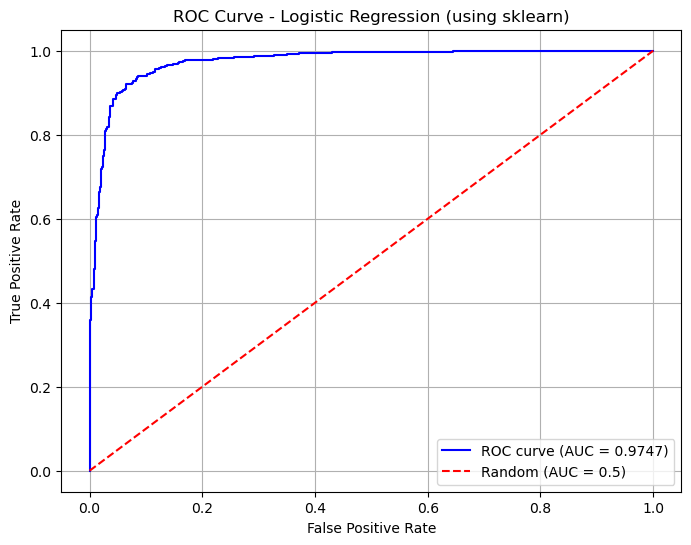

In [91]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (using sklearn)')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
# 3.4: ROC Curve WITHOUT package 

thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Store FPR and TPR for each threshold
manual_fpr = []
manual_tpr = []

# Calculate for each threshold
for t in thresholds:
    # Predict based on threshold
    y_pred_t = (y_prob >= t).astype(int)
    
    # Count TP, TN, FP, FN
    TP = sum((y_pred_t == 1) & (y_test == 1))
    TN = sum((y_pred_t == 0) & (y_test == 0))
    FP = sum((y_pred_t == 1) & (y_test == 0))
    FN = sum((y_pred_t == 0) & (y_test == 1))
    
    # Calculate FPR and TPR
    if (FP + TN) > 0:
        fpr_val = FP / (FP + TN)
    else:
        fpr_val = 0
    
    if (TP + FN) > 0:
        tpr_val = TP / (TP + FN)
    else:
        tpr_val = 0
    
    manual_fpr.append(fpr_val)
    manual_tpr.append(tpr_val)

print("Manual ROC Curve points:")
print(pd.DataFrame({'Threshold': thresholds, 'FPR': manual_fpr, 'TPR': manual_tpr}))

Manual ROC Curve points:
    Threshold       FPR       TPR
0         0.0  1.000000  1.000000
1         0.1  0.307692  0.987368
2         0.2  0.152367  0.968421
3         0.3  0.091716  0.938947
4         0.4  0.063609  0.909474
5         0.5  0.038462  0.867368
6         0.6  0.034024  0.829474
7         0.7  0.026627  0.787368
8         0.8  0.022189  0.717895
9         0.9  0.011834  0.600000
10        1.0  0.000000  0.002105


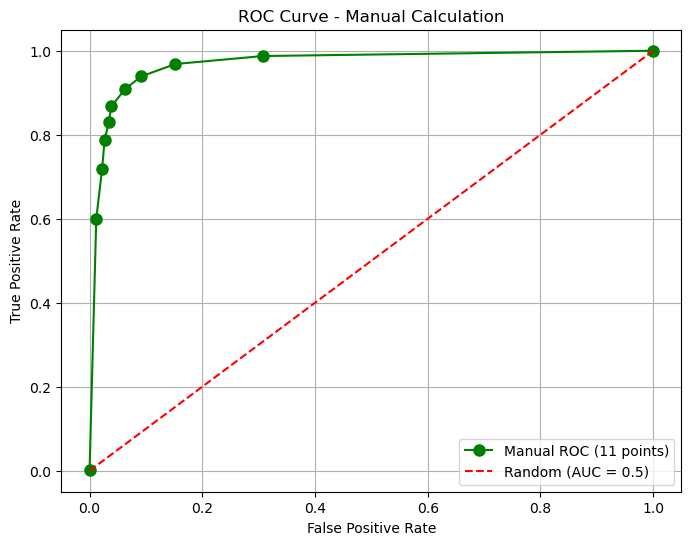

In [93]:
# Plot manual ROC curve
plt.figure(figsize=(8, 6))
plt.plot(manual_fpr, manual_tpr, 'go-', markersize=8, label='Manual ROC (11 points)')
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Manual Calculation')
plt.legend()
plt.grid(True)
plt.show()

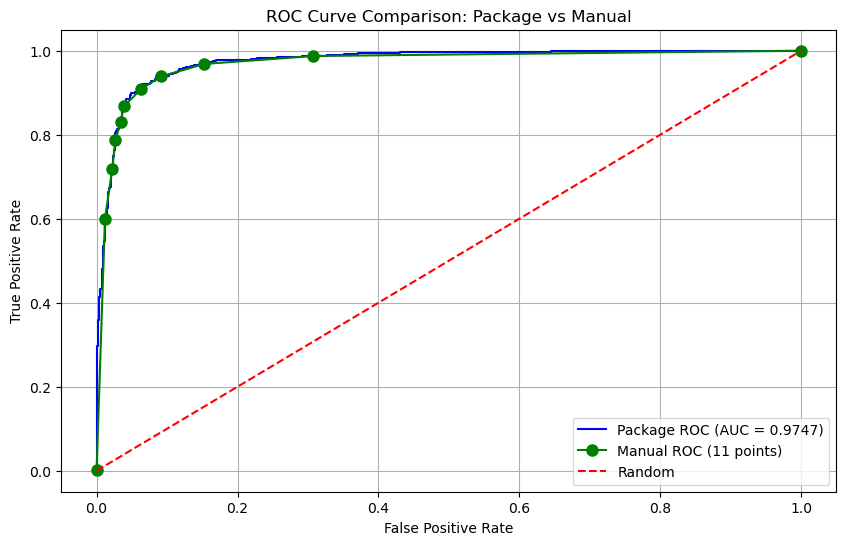

In [94]:
# Compare both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', label=f'Package ROC (AUC = {roc_auc:.4f})')
plt.plot(manual_fpr, manual_tpr, 'go-', markersize=8, label='Manual ROC (11 points)')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Package vs Manual')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
# Differences and how to make them more similar
print("1. Number of points:")
print(f"Package ROC: {len(fpr)} points")
print(f"Manual ROC: {len(manual_fpr)} points (only 11)\n")

print("2. How to make them more similar:")
print("Use more thresholds")

1. Number of points:
Package ROC: 164 points
Manual ROC: 11 points (only 11)

2. How to make them more similar:
Use more thresholds


## [C] Problem 4: Cross validation (25 points)

In [96]:
# 4.1: Prepare the full dataset for cross-validation

# All features
X_full = df.iloc[:, :-1]  
# Labels
y_full = df.iloc[:, -1]    

# Scale the features
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# Convert y to numpy array
y_full = y_full.values

print("X_full_scaled shape:", X_full_scaled.shape)
print("y_full shape:", y_full.shape)
print("Total samples:", len(y_full))

X_full_scaled shape: (4601, 57)
y_full shape: (4601,)
Total samples: 4601


In [97]:
# Define our own k-fold cross validation function

def my_kfold_cv(X, y, model, k):
    """
    Parameters:
    X : numpy, array The features (input data)
    y : numpy, array The labels (what we're predicting)
    model : The model to evaluate 
    k : int, Number of folds
    
    Returns:
    avg_error : float, The average error across all k folds
    fold_errors : list, The error for each individual fold
    """
    
    n = len(X)
    np.random.seed(42) 
    indices = np.random.permutation(n)
    
    # Calculate the size of each fold
    fold_size = n // k
    
    # Empty list for storing error for each fold
    fold_errors = []
    
    for i in range(k):
        
        # Determine start and end indices for validation set
        start = i * fold_size
        if i == k - 1:
            # Last fold gets all remaining samples (extra 1)
            end = n
        else:
            end = start + fold_size
        
        # Get validation indices and training indices
        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        
        # Split the data
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Train the model (create a fresh copy first)
        model_copy = clone(model)
        model_copy.fit(X_train_fold, y_train_fold)
        
        # Make predictions on validation set
        y_pred_fold = model_copy.predict(X_val_fold)
        
        # Calculate error for this fold
        accuracy = accuracy_score(y_val_fold, y_pred_fold)
        error = 1 - accuracy
        fold_errors.append(error)
    
    # Calculate average error
    avg_error = np.mean(fold_errors)
    
    return avg_error, fold_errors

# Test
test_model = LogisticRegression(max_iter=1000, random_state=42)
avg_error, fold_errors = my_kfold_cv(X_full_scaled, y_full, test_model, k=5)

print(f"Errors for each fold: {[round(e, 4) for e in fold_errors]}")
print(f"Average error: {round(avg_error, 4)}")
print(f"Average accuracy: {round(1 - avg_error, 4)}")

Errors for each fold: [0.0804, 0.0761, 0.0793, 0.0717, 0.0706]
Average error: 0.0756
Average accuracy: 0.9244


In [98]:
# 4.2: CV for LR and LDA when k = [5, 10]

# Run cross validation for Logistic Regression and LDA
# With k=5 and k=10

# Define the models in a dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Define k values to test
k_values = [5, 10]

# Store results
results = []

# Loop through each model and each k value
for model_name, model in models.items():
    for k in k_values:
        avg_err, fold_errs = my_kfold_cv(X_full_scaled, y_full, model, k)
        results.append({
            'Model': model_name,
            'k': k,
            'Avg Error': round(avg_err, 4),
            'Avg Accuracy': round(1 - avg_err, 4)
        })

# Results
results_df = pd.DataFrame(results)
print(results_df)

                 Model   k  Avg Error  Avg Accuracy
0  Logistic Regression   5     0.0756        0.9244
1  Logistic Regression  10     0.0737        0.9263
2                  LDA   5     0.1126        0.8874
3                  LDA  10     0.1130        0.8870


### 4.3 Model Comparison:

Logistic Regression:
- k=5:  Error = 0.0756 (Accuracy = 92.44%)
- k=10: Error = 0.0737 (Accuracy = 92.63%)

LDA:
- k=5:  Error = 0.1126 (Accuracy = 88.74%)
- k=10: Error = 0.1130 (Accuracy = 88.70%)

- Logistic Regression is the BETTER model for SPAM classification, achieves ≈92.5% accuracy